In [1]:
import numpy as np
from src import util

from src.linear_model import LinearModel

In [2]:
class LogisticRegression(LinearModel):
    """Logistic regression with Newton's Method as the solver.

    Example usage:
        > clf = LogisticRegression()
        > clf.fit(x_train, y_train)
        > clf.predict(x_eval)
    """
    def fit(self, x, y):
        """Run Newton's Method to minimize J(theta) for logistic regression.

        Args:
            x: Training example inputs. Shape (m, n).
            y: Training example labels. Shape (m,).
        """
        m,n=x.shape
        self.theta=np.zeros(n)
        def sigmoid(z):
            return 1/(1+np.e**(-z))

        def gradient(y,x,theta):
            return -1/len(y)*x.T@(y-sigmoid(x@theta))+theta*1e-5  
        def hessian(x,theta):
            m = x.shape[0]
            h=sigmoid(x@theta)
            h = np.clip(h, 1e-15, 1 - 1e-15)
            S = np.diag(h * (1 - h))
            return (1/m) * x.T@S@x+1e-5 * np.eye(x.shape[1])
        theta_pr=np.array(self.theta)+1
        while np.linalg.norm(self.theta-theta_pr,ord=1)>=self.eps:
            theta_pr=np.copy(self.theta)
            self.theta=self.theta- np.linalg.inv(hessian(x,self.theta))@gradient(y,x,self.theta)
            #print(self.theta)
        

    def predict(self, x):
        """Make a prediction given new inputs x.

        Args:
            x: Inputs of shape (m, n).

        Returns:
            Outputs of shape (m,).
        """
        return (0.5<=1/(1+np.exp(-(x @ self.theta)))).astype(int)

In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
def plot_line_with_data(x,y,theta,title):
    fig,ax=plt.subplots()
    sns.scatterplot(x=x[:,1],y=x[:,2],hue=y)
    def calculate_x2(x1,theta):
        return -(theta[0]+theta[1]*x1)/theta[2]
    x_min=np.min(x[:,1])
    x_max=np.max(x[:,1])
    
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(title)
    plt.plot([x_min,x_max ], [calculate_x2(x_min,theta), calculate_x2(x_max,theta)], linewidth=2,color='red')
    plt.show()

In [5]:
x_test, y_test = util.load_dataset("data/ds3_test.csv", add_intercept=True)
_, t_test = util.load_dataset('data/ds3_test.csv', label_col='t')

x_train3, y_train3= util.load_dataset("data/ds3_train.csv", add_intercept=True)
_, t_train3 = util.load_dataset('data/ds3_train.csv', label_col='t')

x_val3, y_val3 = util.load_dataset("data/ds3_valid.csv", add_intercept=True)
_, t_val3 = util.load_dataset('data/ds3_valid.csv', label_col='t')


In [6]:
lr=LogisticRegression()
lr.fit(x_train3,t_train3)
lr_predictions=lr.predict(x_test)
f"accuracy of lr on true values: {(lr_predictions==t_test).sum()/len(t_test)*100}%"

'accuracy of lr on true values: 98.38709677419355%'

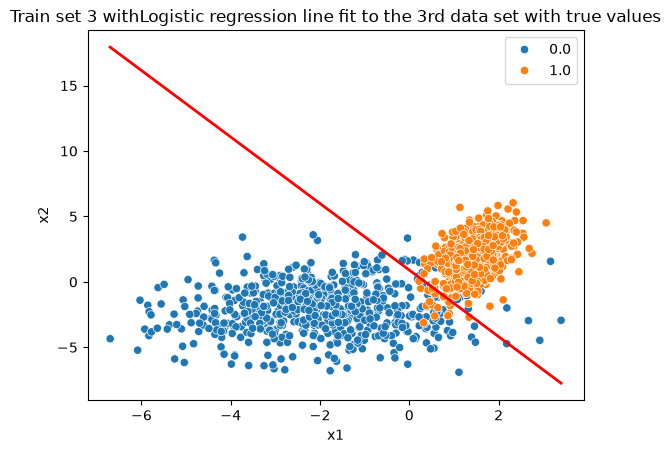

In [7]:
plot_line_with_data(x_train3,t_train3,lr.theta,"Train set 3 withLogistic regression line fit to the 3rd data set with true values")

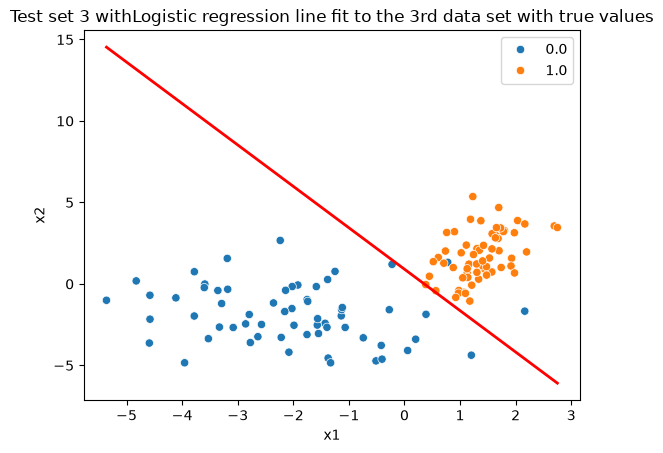

In [8]:
plot_line_with_data(x_test,t_test,lr.theta,"Test set 3 withLogistic regression line fit to the 3rd data set with true values")

In [9]:
lr=LogisticRegression()
lr.fit(x_train3,y_train3)
lr_predictions=lr.predict(x_test)
f"accuracy of lr on y values: {(lr_predictions==t_test).sum()/len(t_test)*100}%"

'accuracy of lr on y values: 50.0%'

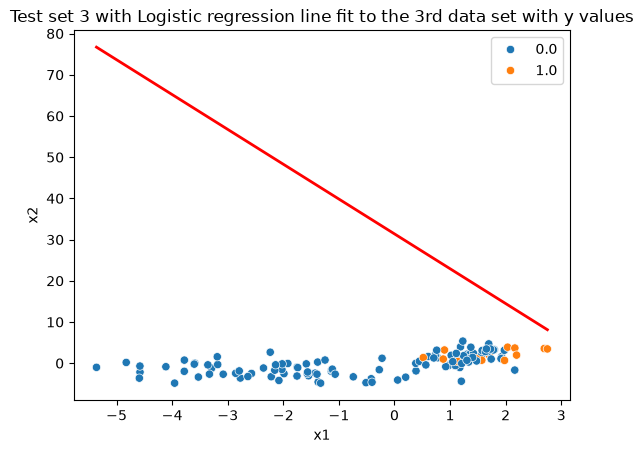

In [10]:
plot_line_with_data(x_test,y_test,lr.theta,"Test set 3 with Logistic regression line fit to the 3rd data set with y values")

In [11]:
V_plus_count=(y_val3==1).sum()
V_plus=x_val3[y_val3==1]
def h(x,theta):
    return 1/(1+np.exp(-(x@theta)))
alpha=np.sum(h(V_plus,lr.theta))/V_plus_count

In [12]:
def predict(x,theta,alpha):
    return (0.5<=h(x,theta)/alpha).astype(int)

In [13]:
predictions=predict(x_val3,lr.theta,alpha)

In [14]:
f"accuracy of lr on y values with adjustment: {(predictions==t_val3).sum()/len(t_val3)*100}%"

'accuracy of lr on y values with adjustment: 95.16129032258065%'

In [15]:
theta_adj=np.copy(lr.theta)
theta_adj[0]+=np.log(2/alpha+1)

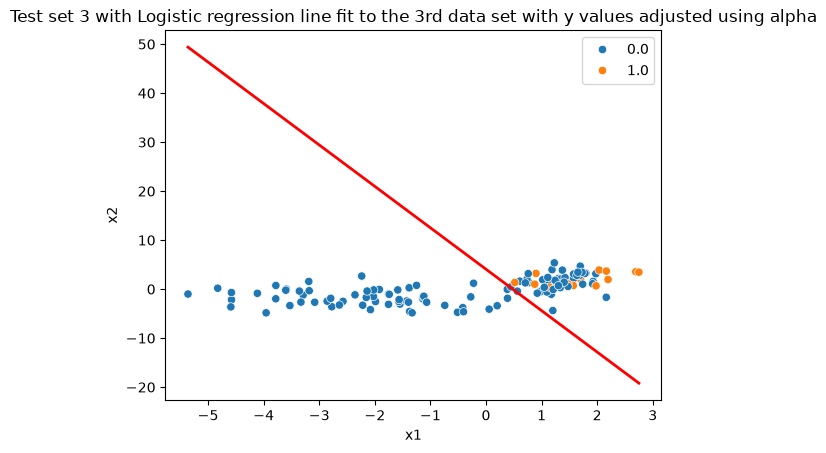

In [16]:
plot_line_with_data(x_test,y_test,theta_adj,"Test set 3 with Logistic regression line fit to the 3rd data set with y values adjusted using alpha")